# Task 3.3 — Performance Evaluation

Compute **Precision / Recall / F1-score** for each method (Jaccard, Lazo, Embedding) against the manually labeled ground truth.

Breakdowns:
- **High** (all 3 methods agree, n=50)
- **Medium** overall (any 2 methods agree, n=150) + sub-groups **J+L**, **J+E**, **L+E** (n=50 each)
- **Low** (only 1 method agrees, n=50)
- **Overall** (all 300 labeled pairs)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

GT_PATH = '../../Data/ground_truth_candidates - Desmond.csv'

df = pd.read_csv(GT_PATH)

# --- thresholds (must match phase3.ipynb) ---
J_THRESH = 0.5
L_THRESH = 0.5
E_THRESH = 0.0   # strictly greater

df['j_vote'] = (df['jaccard_score']   >= J_THRESH).astype(int)
df['l_vote'] = (df['lazo_score']      >= L_THRESH).astype(int)
df['e_vote'] = (df['embedding_score'] >  E_THRESH).astype(int)

# ground truth: y=1, n=0
df['label'] = (df['y/n'].str.strip().str.lower() == 'y').astype(int)

# sub-group tag
def subgroup(row):
    j, l, e = row['j_vote'], row['l_vote'], row['e_vote']
    if   j==1 and l==1 and e==1: return 'high'
    elif j==1 and l==1 and e==0: return 'medium_JL'
    elif j==1 and l==0 and e==1: return 'medium_JE'
    elif j==0 and l==1 and e==1: return 'medium_LE'
    elif j==1 and l==0 and e==0: return 'low_J'
    elif j==0 and l==1 and e==0: return 'low_L'
    elif j==0 and l==0 and e==1: return 'low_E'
    else:                         return 'negative'

df['subgroup'] = df.apply(subgroup, axis=1)

print(df['subgroup'].value_counts())
print(f"\nTotal pairs: {len(df)}  |  joinable (y): {df['label'].sum()}  |  not joinable (n): {(df['label']==0).sum()}")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


subgroup
high         50
medium_JL    50
medium_JE    50
medium_LE    50
negative     50
low_E        18
low_J        16
low_L        16
Name: count, dtype: int64

Total pairs: 300  |  joinable (y): 171  |  not joinable (n): 129


In [2]:
def prf(y_true, y_pred):
    """Return dict of TP/FP/FN/TN/Precision/Recall/F1 for positive class."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else float('nan')
    return dict(TP=tp, FP=fp, FN=fn, TN=tn, n=len(y_true),
                Precision=round(prec,4), Recall=round(rec,4), F1=round(f1,4))


METHODS = {'Jaccard': 'j_vote', 'Lazo': 'l_vote', 'Embedding': 'e_vote'}

GROUPS = {
    'High (J+L+E)':  df['subgroup'] == 'high',
    'Medium — J+L':  df['subgroup'] == 'medium_JL',
    'Medium — J+E':  df['subgroup'] == 'medium_JE',
    'Medium — L+E':  df['subgroup'] == 'medium_LE',
    'Medium (all)':  df['subgroup'].isin(['medium_JL','medium_JE','medium_LE']),
    'Low':           df['subgroup'].isin(['low_J','low_L','low_E']),
    'Negative':      df['subgroup'] == 'negative',
    'Overall (300)': pd.Series([True]*len(df), index=df.index),
}

rows = []
for group_name, mask in GROUPS.items():
    sub = df[mask]
    for method_name, vote_col in METHODS.items():
        stats = prf(sub['label'], sub[vote_col])
        rows.append({'Group': group_name, 'Method': method_name, **stats})

results = pd.DataFrame(rows)
results

,Group,Method,TP,FP,FN,TN,n,Precision,Recall,F1
0,High (J+L+E),Jaccard,48,2,0,0,50,0.9600,1.0000,0.9796
1,High (J+L+E),Lazo,48,2,0,0,50,0.9600,1.0000,0.9796
2,High (J+L+E),Embedding,48,2,0,0,50,0.9600,1.0000,0.9796
3,Medium — J+L,Jaccard,48,2,0,0,50,0.9600,1.0000,0.9796
4,Medium — J+L,Lazo,48,2,0,0,50,0.9600,1.0000,0.9796
5,Medium — J+L,Embedding,0,0,48,2,50,NaN,0.0000,NaN
6,Medium — J+E,Jaccard,16,34,0,0,50,0.3200,1.0000,0.4848
7,Medium — J+E,Lazo,0,0,16,34,50,NaN,0.0000,NaN
8,Medium — J+E,Embedding,16,34,0,0,50,0.3200,1.0000,0.4848
9,Medium — L+E,Jaccard,0,0,49,1,50,NaN,0.0000,NaN


In [3]:
# --- Formatted summary: Precision / Recall / F1 ---
method_order = ['Jaccard', 'Lazo', 'Embedding']
group_order  = list(GROUPS.keys())

summary = results.pivot_table(
    index='Group', columns='Method',
    values=['Precision', 'Recall', 'F1'],
    aggfunc='first'
).reindex(columns=pd.MultiIndex.from_product(
    [['Precision','Recall','F1'], method_order]
)).reindex(group_order)

# Add positive rate column for reference
pos_rates = [round(df[mask]['label'].mean(), 3) for mask in GROUPS.values()]
summary.insert(0, ('Pos rate', ''), pos_rates)

pd.set_option('display.float_format', '{:.4f}'.format)
print(summary.to_string())

              Pos rate Precision                   Recall                       F1                 
                         Jaccard   Lazo Embedding Jaccard   Lazo Embedding Jaccard   Lazo Embedding
Group                                                                                              
High (J+L+E)    0.9600    0.9600 0.9600    0.9600  1.0000 1.0000    1.0000  0.9796 0.9796    0.9796
Medium — J+L    0.9600    0.9600 0.9600       NaN  1.0000 1.0000    0.0000  0.9796 0.9796       NaN
Medium — J+E    0.3200    0.3200    NaN    0.3200  1.0000 0.0000    1.0000  0.4848    NaN    0.4848
Medium — L+E    0.9800       NaN 0.9800    0.9800  0.0000 1.0000    1.0000     NaN 0.9899    0.9899
Medium (all)    0.7530    0.6400 0.9700    0.6500  0.5664 0.8584    0.5752  0.6009 0.9108    0.6103
Low             0.2000    0.1875 0.4375    0.0000  0.3000 0.7000    0.0000  0.2308 0.5385       NaN
Negative        0.0000       NaN    NaN       NaN     NaN    NaN       NaN     NaN    NaN       NaN


In [4]:
# --- TP / FP / FN / TN detail ---
conf_table = results[['Group','Method','TP','FP','FN','TN','n']].set_index(['Group','Method'])
print(conf_table.to_string())

                          TP  FP  FN   TN    n
Group         Method                          
High (J+L+E)  Jaccard     48   2   0    0   50
              Lazo        48   2   0    0   50
              Embedding   48   2   0    0   50
Medium — J+L  Jaccard     48   2   0    0   50
              Lazo        48   2   0    0   50
              Embedding    0   0  48    2   50
Medium — J+E  Jaccard     16  34   0    0   50
              Lazo         0   0  16   34   50
              Embedding   16  34   0    0   50
Medium — L+E  Jaccard      0   0  49    1   50
              Lazo        49   1   0    0   50
              Embedding   49   1   0    0   50
Medium (all)  Jaccard     64  36  49    1  150
              Lazo        97   3  16   34  150
              Embedding   65  35  48    2  150
Low           Jaccard      3  13   7   27   50
              Lazo         7   9   3   31   50
              Embedding    0  18  10   22   50
Negative      Jaccard      0   0   0   50   50
             

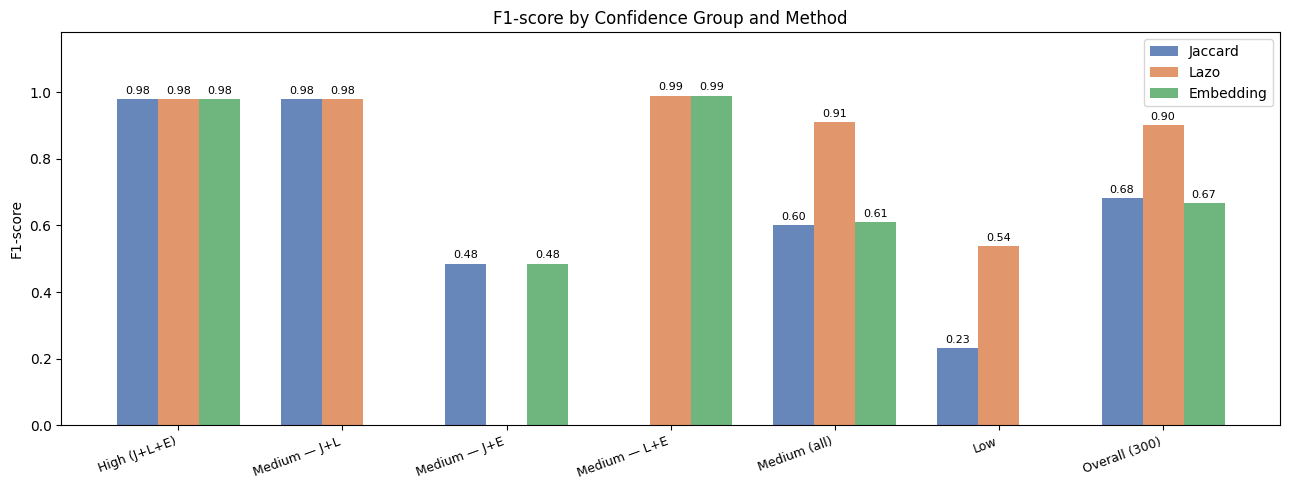

Saved → Data/f1_by_group.png


In [5]:
# --- Bar chart: F1-score across groups ---
plot_groups = [
    'High (J+L+E)',
    'Medium — J+L', 'Medium — J+E', 'Medium — L+E',
    'Medium (all)',
    'Low',
    'Overall (300)',
]
f1_data = results[results['Group'].isin(plot_groups)].pivot(
    index='Group', columns='Method', values='F1'
).reindex(plot_groups)[method_order]

x     = np.arange(len(plot_groups))
w     = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (method, color) in enumerate(zip(method_order, colors)):
    vals = f1_data[method].values.astype(float)
    bars = ax.bar(x + (i-1)*w, vals, w, label=method, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(plot_groups, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.18)
ax.set_ylabel('F1-score')
ax.set_title('F1-score by Confidence Group and Method')
ax.legend()
plt.tight_layout()
plt.savefig('../../Data/f1_by_group.png', dpi=150)
plt.show()
print('Saved → Data/f1_by_group.png')

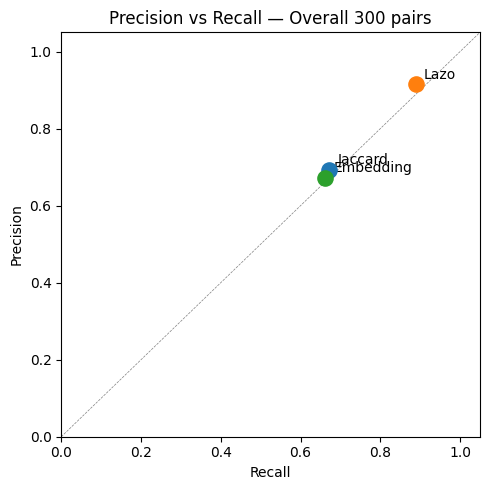

Saved → Data/pr_scatter_overall.png


In [6]:
# --- Precision-Recall scatter: Overall 300 ---
overall = results[results['Group'] == 'Overall (300)']

fig, ax = plt.subplots(figsize=(5, 5))
for _, row in overall.iterrows():
    ax.scatter(row['Recall'], row['Precision'], s=120, zorder=5)
    ax.annotate(row['Method'],
                (row['Recall'], row['Precision']),
                textcoords='offset points', xytext=(6, 4), fontsize=10)

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall — Overall 300 pairs')
ax.axline((0, 0), slope=1, color='grey', lw=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('../../Data/pr_scatter_overall.png', dpi=150)
plt.show()
print('Saved → Data/pr_scatter_overall.png')